# KG Extraction

In [1]:
import pandas as pd

df = pd.read_csv("kg_output_csv/target_compounds_raw.csv")

print("Original shape:", df.shape)
df.head()

Original shape: (216, 6)


,gene,compound,compound_code,cui,relationship,source
0,NR1H2 gene,(R)-5-{4-[2-(Methyl-pyridin-2-yl-amino)-ethoxy...,10021239,C0289313,negatively_correlated_with_chemical_or_drug,CMAP
1,NR1H2 gene,(R)-5-{4-[2-(Methyl-pyridin-2-yl-amino)-ethoxy...,10021239,C0289313,inverse_negatively_correlated_with_chemical_or...,CMAP
2,NR1H2 gene,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth...",4302962,PUBCHEM:4302962 CUI,negatively_regulates,LINCS
3,NR1H2 gene,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth...",4302962,PUBCHEM:4302962 CUI,negatively_regulated_by,LINCS
4,NR1H2 gene,1-phenylbiguanide,4780,PUBCHEM:4780 CUI,positively_regulates,LINCS


In [2]:
#remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

print("Clean shape:", df_clean.shape)
print("Unique compounds:", df_clean["compound"].nunique())
print("Targets:", df_clean["gene"].unique())

Clean shape: (216, 6)
Unique compounds: 99
Targets: <StringArray>
['NR1H2 gene', 'NR1H3 gene', 'TYROBP gene']
Length: 3, dtype: str


In [3]:
#counts target counts
compound_counts = (
    df_clean.groupby("gene")["compound"]
    .nunique()
    .reset_index(name="unique_compound_count")
)

compound_counts

,gene,unique_compound_count
0,NR1H2 gene,42
1,NR1H3 gene,43
2,TYROBP gene,22


In [4]:
#relationship type counts
relationship_counts = (
    df_clean.groupby(["gene", "relationship"])
    .size()
    .reset_index(name="count")
    .sort_values(["gene", "count"], ascending=[True, False])
)

relationship_counts

,gene,relationship,count
0,NR1H2 gene,inverse_negatively_correlated_with_chemical_or...,31
2,NR1H2 gene,negatively_correlated_with_chemical_or_drug,31
6,NR1H2 gene,positively_regulated_by,6
7,NR1H2 gene,positively_regulates,6
1,NR1H2 gene,inverse_positively_correlated_with_chemical_or...,3
3,NR1H2 gene,negatively_regulated_by,3
4,NR1H2 gene,negatively_regulates,3
5,NR1H2 gene,positively_correlated_with_chemical_or_drug,3
8,NR1H3 gene,inverse_negatively_correlated_with_chemical_or...,36
10,NR1H3 gene,negatively_correlated_with_chemical_or_drug,36


In [5]:
#source counts
source_counts = (
    df_clean.groupby(["gene", "source"])
    .size()
    .reset_index(name="count")
    .sort_values(["gene", "count"], ascending=[True, False])
)

source_counts

,gene,source,count
0,NR1H2 gene,CMAP,68
1,NR1H2 gene,LINCS,18
2,NR1H3 gene,CMAP,82
3,NR1H3 gene,LINCS,4
4,TYROBP gene,LINCS,44


In [6]:
#save all cleaned compound-neighbor rows
df_clean.to_csv("jupyter_output/all_target_compounds_cleaned.csv", index=False)

#save unique compound list for PubChem
unique_compounds = (
    df_clean[["compound"]]
    .drop_duplicates()
    .sort_values("compound")
    .reset_index(drop=True)
)

unique_compounds.to_csv("jupyter_output/unique_compounds_for_pubchem.csv", index=False)

unique_compounds.head()

,compound
0,"(-)-Phenyl-carbamic acid 1,3a,8-trimethyl-1,2,..."
1,(R)-5-{4-[2-(Methyl-pyridin-2-yl-amino)-ethoxy...
2,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth..."
3,1-phenylbiguanide
4,"3-(dibenzo[b,e]oxepin-11(6H)-ylidene)-N,N-dime..."


In [7]:
print("Saved:")
print("all_target_compounds_cleaned.csv")
print("unique_compounds_for_pubchem.csv")

Saved:
all_target_compounds_cleaned.csv
unique_compounds_for_pubchem.csv


# PubChem annotation API

In [8]:
import pandas as pd
import requests
import time
from urllib.parse import quote

#load unique compounds from KG extraction step
compounds_df = pd.read_csv("jupyter_output/unique_compounds_for_pubchem.csv")

print(compounds_df.shape)
compounds_df.head()

(99, 1)


,compound
0,"(-)-Phenyl-carbamic acid 1,3a,8-trimethyl-1,2,..."
1,(R)-5-{4-[2-(Methyl-pyridin-2-yl-amino)-ethoxy...
2,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth..."
3,1-phenylbiguanide
4,"3-(dibenzo[b,e]oxepin-11(6H)-ylidene)-N,N-dime..."


In [9]:
def get_pubchem_info(compound_name):
    """
    Search PubChem by compound name and return basic annotation.
    """
    base_url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"
    encoded_name = quote(str(compound_name))

    #1: get CID
    cid_url = f"{base_url}/compound/name/{encoded_name}/cids/JSON"

    try:
        cid_response = requests.get(cid_url, timeout=10)

        if cid_response.status_code != 200:
            return {
                "compound": compound_name,
                "pubchem_cid": None,
                "canonical_smiles": None,
                "molecular_formula": None,
                "molecular_weight": None,
                "iupac_name": None,
                "pubchem_status": "CID not found"
            }

        cid_data = cid_response.json()
        cid = cid_data["IdentifierList"]["CID"][0]

        # 2: get compound properties
        props = "CanonicalSMILES,MolecularFormula,MolecularWeight,IUPACName"
        prop_url = f"{base_url}/compound/cid/{cid}/property/{props}/JSON"

        prop_response = requests.get(prop_url, timeout=10)

        if prop_response.status_code != 200:
            return {
                "compound": compound_name,
                "pubchem_cid": cid,
                "canonical_smiles": None,
                "molecular_formula": None,
                "molecular_weight": None,
                "iupac_name": None,
                "pubchem_status": "CID found, properties missing"
            }

        prop_data = prop_response.json()
        prop = prop_data["PropertyTable"]["Properties"][0]

        return {
            "compound": compound_name,
            "pubchem_cid": cid,
            "canonical_smiles": prop.get("CanonicalSMILES"),
            "molecular_formula": prop.get("MolecularFormula"),
            "molecular_weight": prop.get("MolecularWeight"),
            "iupac_name": prop.get("IUPACName"),
            "pubchem_status": "found"
        }

    except Exception as e:
        return {
            "compound": compound_name,
            "pubchem_cid": None,
            "canonical_smiles": None,
            "molecular_formula": None,
            "molecular_weight": None,
            "iupac_name": None,
            "pubchem_status": f"error: {e}"
        }

In [10]:
results = []

for i, compound in enumerate(compounds_df["compound"], start=1):
    print(f"{i}/{len(compounds_df)}: {compound}")

    #getting
    info = get_pubchem_info(compound)
    results.append(info)

    # timeout
    time.sleep(0.2)

pubchem_df = pd.DataFrame(results)

pubchem_df.head()

1/99: (-)-Phenyl-carbamic acid 1,3a,8-trimethyl-1,2,3,3a,8,8a-hexahydro-pyrrolo[2,3-b]indol-5-yl ester
2/99: (R)-5-{4-[2-(Methyl-pyridin-2-yl-amino)-ethoxy]-benzyl}-thiazolidine-2,4-dione
3/99: 1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-methyl-N-morpholino-1H-pyrazole-3-carboxamide
4/99: 1-phenylbiguanide
5/99: 3-(dibenzo[b,e]oxepin-11(6H)-ylidene)-N,N-dimethylpropan-1-amine
6/99: 3-{2-[4-(6-Fluoro-benzo[d]isoxazol-3-yl)-piperidin-1-yl]-ethyl}-2-methyl-6,7,8,9-tetrahydro-pyrido[1,2-a]pyrimidin-4-one (Resperidone)
7/99: 4-Amino-1-(5-hydroxymethyl-tetrahydro-furan-2-yl)-1H-pyrimidin-2-one
8/99: 4-Amino-N-(2-diethylamino-ethyl)-benzamide
9/99: 5-(4-Chloro-phenyl)-6-ethyl-pyrimidine-2,4-diamine
10/99: 7,8-dihydroxy-6-methoxy-2H-chromen-2-one
11/99: 8-[4-(4-Pyrimidin-2-yl-piperazin-1-yl)-butyl]-8-aza-spiro[4.5]decane-7,9-dione (Buspirone)
12/99: Acetohexamide
13/99: Acyclovir
14/99: Altizide
15/99: Amphotericin B
16/99: BG-1018
17/99: Benzocaine
18/99: Bromopride
19/99: Bromperidol
20/99: CG

,compound,pubchem_cid,canonical_smiles,molecular_formula,molecular_weight,iupac_name,pubchem_status
0,"(-)-Phenyl-carbamic acid 1,3a,8-trimethyl-1,2,...",NaN,None,NaN,NaN,NaN,CID not found
1,(R)-5-{4-[2-(Methyl-pyridin-2-yl-amino)-ethoxy...,NaN,None,NaN,NaN,NaN,CID not found
2,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth...",4302962.0,None,C21H19Cl2IN4O2,557.2,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth...",found
3,1-phenylbiguanide,4780.0,None,C8H11N5,177.21,1-(diaminomethylidene)-2-phenylguanidine,found
4,"3-(dibenzo[b,e]oxepin-11(6H)-ylidene)-N,N-dime...",3158.0,None,C19H21NO,279.4,"3-(6H-benzo[c][1]benzoxepin-11-ylidene)-N,N-di...",found


In [11]:
print("Total compounds:", len(pubchem_df))
print("Found in PubChem:", (pubchem_df["pubchem_status"] == "found").sum())
print("Not found/errors:", (pubchem_df["pubchem_status"] != "found").sum())

pubchem_df["pubchem_status"].value_counts()

Total compounds: 99
Found in PubChem: 75
Not found/errors: 24


pubchem_status
found            75
CID not found    24
Name: count, dtype: int64

In [12]:
#save PubChem annotations
pubchem_df.to_csv("jupyter_output/pubchem_annotations.csv", index=False)

print("Saved: pubchem_annotations.csv")

Saved: pubchem_annotations.csv


## merge PubChem back to the KG compound table

In [13]:
kg_df = pd.read_csv("jupyter_output/all_target_compounds_cleaned.csv")
pubchem_df = pd.read_csv("jupyter_output/pubchem_annotations.csv")

merged_df = kg_df.merge(pubchem_df, on="compound", how="left")

print(merged_df.shape)
merged_df.head()

(216, 12)


,gene,compound,compound_code,cui,relationship,source,pubchem_cid,canonical_smiles,molecular_formula,molecular_weight,iupac_name,pubchem_status
0,NR1H2 gene,(R)-5-{4-[2-(Methyl-pyridin-2-yl-amino)-ethoxy...,10021239,C0289313,negatively_correlated_with_chemical_or_drug,CMAP,NaN,NaN,NaN,NaN,NaN,CID not found
1,NR1H2 gene,(R)-5-{4-[2-(Methyl-pyridin-2-yl-amino)-ethoxy...,10021239,C0289313,inverse_negatively_correlated_with_chemical_or...,CMAP,NaN,NaN,NaN,NaN,NaN,CID not found
2,NR1H2 gene,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth...",4302962,PUBCHEM:4302962 CUI,negatively_regulates,LINCS,4302962.0,NaN,C21H19Cl2IN4O2,557.20,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth...",found
3,NR1H2 gene,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth...",4302962,PUBCHEM:4302962 CUI,negatively_regulated_by,LINCS,4302962.0,NaN,C21H19Cl2IN4O2,557.20,"1-(2,4-dichlorophenyl)-5-(4-iodophenyl)-4-meth...",found
4,NR1H2 gene,1-phenylbiguanide,4780,PUBCHEM:4780 CUI,positively_regulates,LINCS,4780.0,NaN,C8H11N5,177.21,1-(diaminomethylidene)-2-phenylguanidine,found


In [14]:
merged_df.to_csv("jupyter_output/kg_compounds_with_pubchem.csv", index=False)

print("Saved: kg_compounds_with_pubchem.csv")

Saved: kg_compounds_with_pubchem.csv


### quick summary table

In [15]:
summary = (
    merged_df.groupby("gene")
    .agg(
        kg_compound_rows=("compound", "count"),
        unique_compounds=("compound", "nunique"),
        pubchem_found=("pubchem_cid", lambda x: x.notna().sum()),
        unique_pubchem_cids=("pubchem_cid", "nunique")
    )
    .reset_index()
)

summary

,gene,kg_compound_rows,unique_compounds,pubchem_found,unique_pubchem_cids
0,NR1H2 gene,86,42,62,30
1,NR1H3 gene,86,43,76,38
2,TYROBP gene,44,22,26,13


In [16]:
summary.to_csv("jupyter_output/pubchem_summary_by_target.csv", index=False)

print("Saved: pubchem_summary_by_target.csv")

Saved: pubchem_summary_by_target.csv


# STRING evidence

In [17]:
import pandas as pd

string_scores = pd.DataFrame({
    "pair": ["TREM2-TYROBP", "ABCA1-NR1H2", "ABCA1-NR1H3", "NR1H3-NR1H2"],
    "gene_1": ["TREM2", "ABCA1", "ABCA1", "NR1H3"],
    "gene_2": ["TYROBP", "NR1H2", "NR1H3", "NR1H2"],
    "string_combined_score": [0.999, 0.991, 0.967, 0.915],
    "interpretation": [
        "Very strong TREM2-TYROBP immune signaling support",
        "Very strong ABCA1-NR1H2 lipid/LXR support",
        "Very strong ABCA1-NR1H3 lipid/LXR support",
        "Strong NR1H3-NR1H2 LXR-family support"
    ]
})

string_scores

,pair,gene_1,gene_2,string_combined_score,interpretation
0,TREM2-TYROBP,TREM2,TYROBP,0.999,Very strong TREM2-TYROBP immune signaling support
1,ABCA1-NR1H2,ABCA1,NR1H2,0.991,Very strong ABCA1-NR1H2 lipid/LXR support
2,ABCA1-NR1H3,ABCA1,NR1H3,0.967,Very strong ABCA1-NR1H3 lipid/LXR support
3,NR1H3-NR1H2,NR1H3,NR1H2,0.915,Strong NR1H3-NR1H2 LXR-family support


In [18]:
string_scores.to_csv("jupyter_output/string_scores.csv", index=False)
print("Saved: string_scores.csv")

Saved: string_scores.csv


In [19]:
kg_pubchem = pd.read_csv("jupyter_output/kg_compounds_with_pubchem.csv")

target_summary = (
    kg_pubchem.groupby("gene")
    .agg(
        kg_compound_rows=("compound", "count"),
        unique_compounds=("compound", "nunique"),
        unique_pubchem_cids=("pubchem_cid", "nunique")
    )
    .reset_index()
)

target_summary

,gene,kg_compound_rows,unique_compounds,unique_pubchem_cids
0,NR1H2 gene,86,42,30
1,NR1H3 gene,86,43,38
2,TYROBP gene,44,22,13


In [20]:
target_summary["target"] = target_summary["gene"].str.replace(" gene", "", regex=False)

mechanism_map = {
    "NR1H2": "LXR-beta; lipid/cholesterol signaling; possible brain/microglia relevance",
    "NR1H3": "LXR-alpha; lipid/cholesterol signaling; ABCA1/APOE lipid biology",
    "TYROBP": "DAP12 adaptor; TREM2 immune/microglial signaling"
}

string_map = {
    "NR1H2": "ABCA1-NR1H2 = 0.991; NR1H3-NR1H2 = 0.915",
    "NR1H3": "ABCA1-NR1H3 = 0.967; NR1H3-NR1H2 = 0.915",
    "TYROBP": "TREM2-TYROBP = 0.999"
}

target_summary["mechanism"] = target_summary["target"].map(mechanism_map)
target_summary["string_evidence"] = target_summary["target"].map(string_map)

target_summary = target_summary[
    ["target", "mechanism", "kg_compound_rows", "unique_compounds", "unique_pubchem_cids", "string_evidence"]
]

target_summary

,target,mechanism,kg_compound_rows,unique_compounds,unique_pubchem_cids,string_evidence
0,NR1H2,LXR-beta; lipid/cholesterol signaling; possibl...,86,42,30,ABCA1-NR1H2 = 0.991; NR1H3-NR1H2 = 0.915
1,NR1H3,LXR-alpha; lipid/cholesterol signaling; ABCA1/...,86,43,38,ABCA1-NR1H3 = 0.967; NR1H3-NR1H2 = 0.915
2,TYROBP,DAP12 adaptor; TREM2 immune/microglial signaling,44,22,13,TREM2-TYROBP = 0.999


In [21]:
target_summary.to_csv("jupyter_output/target_comparison_table.csv", index=False)
print("Saved: target_comparison_table.csv")

Saved: target_comparison_table.csv


## Cool figures

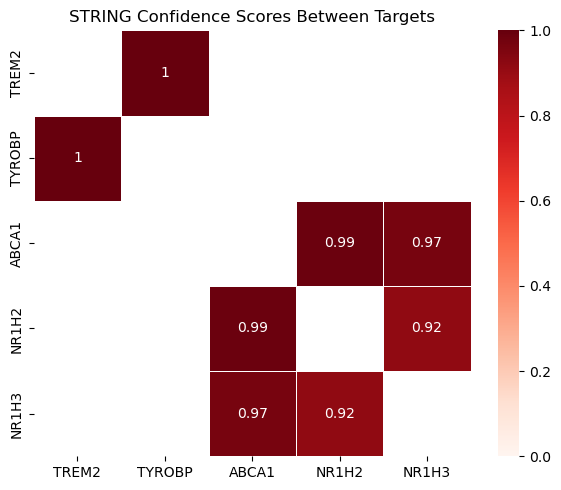

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

string_scores = pd.read_csv("jupyter_output/string_scores.csv")

genes = ["TREM2", "TYROBP", "ABCA1", "NR1H2", "NR1H3"]
matrix = pd.DataFrame(np.nan, index=genes, columns=genes)

for _, row in string_scores.iterrows():
    matrix.loc[row["gene_1"], row["gene_2"]] = row["string_combined_score"]
    matrix.loc[row["gene_2"], row["gene_1"]] = row["string_combined_score"]

plt.figure(figsize=(6,5))
sns.heatmap(matrix, annot=True, cmap="Reds", vmin=0, vmax=1, linewidths=0.5)
plt.title("STRING Confidence Scores Between Targets")
plt.tight_layout()
plt.show()

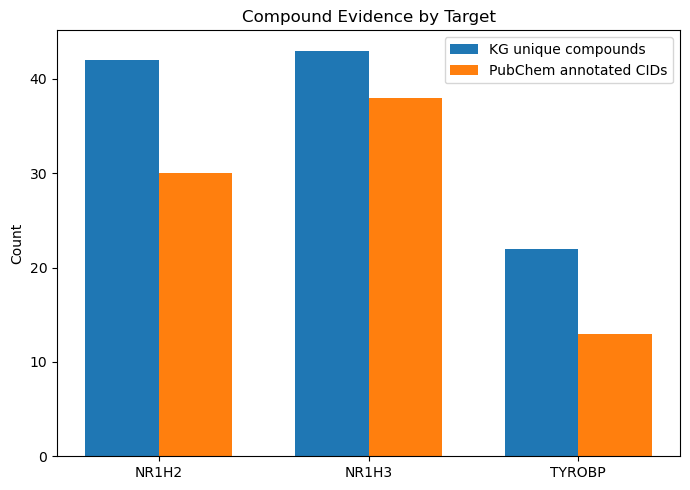

In [9]:
summary = pd.read_csv("jupyter_output/target_comparison_table.csv")

x = np.arange(len(summary))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, summary["unique_compounds"], width, label="KG unique compounds")
plt.bar(x + width/2, summary["unique_pubchem_cids"], width, label="PubChem annotated CIDs")
plt.xticks(x, summary["target"])
plt.ylabel("Count")
plt.title("Compound Evidence by Target")
plt.legend()
plt.tight_layout()
plt.show()

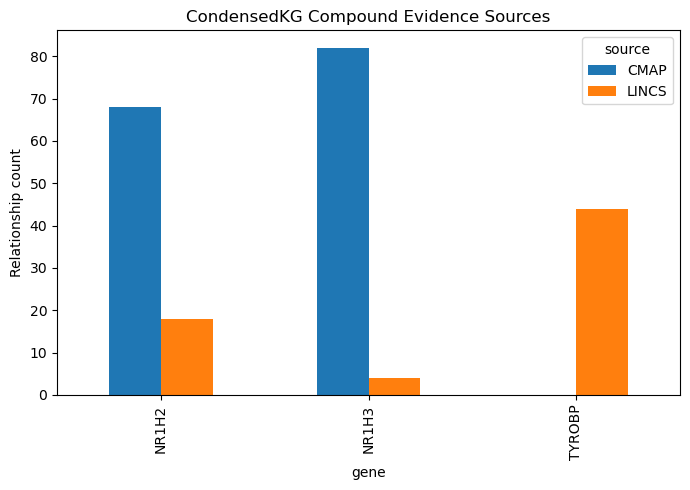

In [10]:
#cell5
source_counts = pd.DataFrame({
    "gene": ["NR1H2", "NR1H2", "NR1H3", "NR1H3", "TYROBP"],
    "source": ["CMAP", "LINCS", "CMAP", "LINCS", "LINCS"],
    "count": [68, 18, 82, 4, 44]
})

pivot = source_counts.pivot(index="gene", columns="source", values="count").fillna(0)

pivot.plot(kind="bar", figsize=(7,5))
plt.ylabel("Relationship count")
plt.title("CondensedKG Compound Evidence Sources")
plt.tight_layout()
plt.show()